# Sensitivity Analysis v2 — Moment-Parameter Jacobian

**Goal:** learn which parameters actually move which moments, respecting the
active moment set defined by `SKIP_MOMENTS`.

**Method:**
1. Load solver and SMM modules from `../solver/` and `../smm/`.
2. Load empirical moments and the covariance matrix Σ̂ from `../data/derived/`
   (produced by `data_pipeline_v6.ipynb`).
3. Set scenario, weights, and `SKIP_MOMENTS` in **Section 3** — identical to
   the solver and data-pipeline notebooks.
4. Solve at the baseline calibration (or loaded estimates).
5. Perturb each of the 26 free parameters by ±10 % (central differences).
6. Compute the Jacobian / elasticity matrix restricted to the **active** moments.
7. Flag weakly-identified parameters (max |elasticity| < 0.1 over active moments).
8. Overlay the Jacobian with the Σ̂ covariance structure to surface
   which moment pairs are both responsive **and** statistically independent.

Uses a coarser grid (`Nx = Np = 60`) and relaxed tolerances for speed.
The full loop (26 params × 2 directions = 52 solves) takes ~2–5 min
depending on thread count.


## 1 · Packages

In [20]:
using LinearAlgebra, SparseArrays, Statistics, Random
using Distributions, FastGaussQuadrature, Interpolations
using Parameters, Printf
using Plots, LaTeXStrings
using Base.Threads
using CSV, DataFrames

Random.seed!(42)


TaskLocalRNG()

## 2 · Load solver and SMM modules

In [21]:
# Notebook lives in  notebooks/
# Solver  lives in  solver/
# SMM     lives in  smm/
const NOTEBOOKS_DIR = @__DIR__
const SOLVER_DIR    = joinpath(NOTEBOOKS_DIR, "..", "solver")
const SMM_DIR       = joinpath(NOTEBOOKS_DIR, "..", "smm")
const PROJECT_ROOT  = joinpath(NOTEBOOKS_DIR, "..", "..")
const OUTPUT_DIR    = joinpath(PROJECT_ROOT, "output")
const ESTIMATES_DIR = joinpath(OUTPUT_DIR, "tables")
const DERIVED_DIR   = joinpath(PROJECT_ROOT, "data", "derived")

include(joinpath(SOLVER_DIR, "grids.jl"))
include(joinpath(SOLVER_DIR, "params.jl"))
include(joinpath(SOLVER_DIR, "unskilled.jl"))
include(joinpath(SOLVER_DIR, "skilled.jl"))
include(joinpath(SOLVER_DIR, "solver.jl"))
include(joinpath(SOLVER_DIR, "equilibrium.jl"))
include(joinpath(SMM_DIR, "moments.jl"))
include(joinpath(SMM_DIR, "smm_params.jl"))   # ← must come before smm.jl
include(joinpath(SMM_DIR, "smm.jl"))

println("Solver + SMM loaded  |  threads: ", Threads.nthreads())


Solver + SMM loaded  |  threads: 10


## 3 · Parameters, scenario, and active moments

Edit `SKIP_MOMENTS`, `ACTIVE_SCENARIO`, `ACTIVE_WEIGHTS`, and `USE_DEFAULT_PARAMS`
here — identical switches to `full_model_ver2_0_solver.ipynb` and
`data_pipeline_v6.ipynb`.  Re-run this cell after any change.


In [22]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  3  ACTIVE MOMENTS, SCENARIO, AND CALIBRATION                               ║
# ║  Change any switch below, then re-run this cell.                            ║
# ║                                                                              ║
# ║  ACTIVE_SCENARIO : :none | :base_fc | :crisis_fc | :base_covid | :crisis_covid ║
# ║  ACTIVE_WEIGHTS  : :full | :diagonal | :compressed | :equal                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Keep SKIP_MOMENTS in sync with smm_main.jl, data_pipeline_v6, and the
#    solver notebook so the Jacobian rows match the covariance matrix columns. ─
SKIP_MOMENTS = Symbol[
    :ur_total,
    #:exp_ur_total,
    #:exp_ur_U,
    :ur_U,
    #:exp_ur_S,
    :ur_S,
    #:exp_ur_S,
    #:skilled_share,
    #:training_share,
    #:emp_var_U,
    #:emp_var_S,
    #:emp_cm3_U,
    #:emp_cm3_S,
    #:ee_rate_S,
    #:p25_wage_U,
    #:p25_wage_S,
    #:p50_wage_U,
    #:p50_wage_S,
    #:mean_wage_U,
    #:mean_wage_S,
    #:sep_rate_S,
    #:jfr_S,
    #:jfr_U,
    #:sep_rate_U,
    #:wage_premium,
]

ACTIVE_SCENARIO    = :base_fc   # ← edit here
ACTIVE_WEIGHTS     = :full      # ← edit here
USE_DEFAULT_PARAMS = false        # ← true = use DEFAULT_PARAMS below; false = load CSV

# ── Solver settings (two tiers) ──────────────────────────────────────────────
const SIM_BASELINE = SimParams(
    tol_inner=1e-8, tol_outer_U=1e-7, tol_outer_S=1e-7, tol_global=1e-4,
    maxit_inner=500, maxit_outer=300, maxit_global=50, conv_streak=2,
    use_anderson=true, anderson_m=1, anderson_reg=1e-10,
    damp_pstar_U=1.00, damp_pstar_S=1.00,
    verbose=2, verbose_stride=10,
)

# Relaxed settings for the 52 sensitivity solves (fast)
const SIM_FAST = SimParams(
    tol_inner=1e-6, tol_outer_U=1e-4, tol_outer_S=1e-4, tol_global=1e-2,
    maxit_inner=500, maxit_outer=300, maxit_global=100, conv_streak=2,
    use_anderson=true, anderson_m=1, anderson_reg=1e-10,
    damp_pstar_U=1.30, damp_pstar_S=0.95,
    verbose=0, verbose_stride=5,
)

const SENS_NX = 60; const SENS_NP = 60

# ── Static lookup tables (const — no redefinition error on re-run) ────────────
const DEFAULT_PARAMS = Dict{Symbol,Float64}(
    :r        => 0.00417,
    :nu       => 0.03841,
    :phi      => 0.02222,
    :a_l      => 1.01131,
    :b_l      => 2.42423,
    :c        => 18.94633,
    :PU       => 0.38948,
    :PS       => 2.23639,
    :bU       => 0.00000,
    :bT       => 0.65082,
    :bS       => 0.56935,
    :alpha_U  => 4.80594,
    :a_Gam    => 4.77377,
    :b_Gam    => 2.28169,
    :unsk_mu  => 0.25585,
    :unsk_eta => 0.66042,
    :unsk_k   => 0.10061,
    :unsk_bet => 0.71642,
    :unsk_lam => 0.25263,
    :skl_mu   => 0.22462,
    :skl_eta  => 0.73213,
    :skl_k    => 0.03317,
    :skl_bet  => 0.80762,
    :skl_xi   => 0.00100,
    :skl_lam  => 0.17788,
    :skl_sig  => 0.00100,
)

const PARAM_SPECS = [
    (:r,        "discount rate r"),
    (:nu,       "demographic exit ν"),
    (:phi,      "training completion φ"),
    (:a_l,      "worker type shape a_ℓ"),
    (:b_l,      "worker type shape b_ℓ"),
    (:c,        "training cost c"),
    (:PU,       "unskilled productivity PU"),
    (:PS,       "skilled productivity PS"),
    (:bU,       "unskilled UI flow bU"),
    (:bT,       "training flow bT"),
    (:bS,       "skilled UI flow bS"),
    (:alpha_U,  "damage shock shape α_U"),
    (:a_Gam,    "skilled offer shape a_Γ"),
    (:b_Gam,    "skilled offer shape b_Γ"),
    (:unsk_mu,  "unskilled matching eff μ_U"),
    (:unsk_eta, "unskilled matching elas η_U"),
    (:unsk_k,   "unskilled vacancy cost k_U"),
    (:unsk_bet, "unskilled bargaining β_U"),
    (:unsk_lam, "unskilled damage rate λ_U"),
    (:skl_mu,   "skilled matching eff μ_S"),
    (:skl_eta,  "skilled matching elas η_S"),
    (:skl_k,    "skilled vacancy cost k_S"),
    (:skl_bet,  "skilled bargaining β_S"),
    (:skl_xi,   "skilled exog sep rate ξ_S"),
    (:skl_lam,  "skilled quality shock λ_S"),
    (:skl_sig,  "OJS flow cost σ"),
]

const PARAM_KEYS   = first.(PARAM_SPECS)
const PARAM_LABELS = last.(PARAM_SPECS)

const SCENARIO_TAGS = Dict{Symbol,String}(
    :base_fc      => "base_fc",
    :crisis_fc    => "crisis_fc",
    :base_covid   => "base_covid",
    :crisis_covid => "crisis_covid",
)

const W_SUFFIX = Dict{Symbol,String}(
    :full       => "_fullW",
    :diagonal   => "_diagonalW",
    :compressed => "_compressedW",
    :equal      => "_equalW",
)

const CSV_KEY_MAP = Dict{Tuple{String,String}, Symbol}(
    ("common","a")    => :a_l,  ("common","b")  => :b_l,   ("common","c")  => :c,
    ("regime","PU")   => :PU,   ("regime","PS") => :PS,    ("regime","bU") => :bU,
    ("regime","bT")   => :bT,   ("regime","bS") => :bS,
    ("regime","U")    => :alpha_U, ("regime","α_U") => :alpha_U,
    ("regime","a")    => :a_Gam,   ("regime","b")   => :b_Gam,
    ("unsk","μ")  => :unsk_mu,   ("unsk","mu")  => :unsk_mu,
    ("unsk","η")  => :unsk_eta,  ("unsk","eta") => :unsk_eta,
    ("unsk","k")  => :unsk_k,
    ("unsk","β")  => :unsk_bet,  ("unsk","bet") => :unsk_bet,
    ("unsk","λ")  => :unsk_lam,  ("unsk","lam") => :unsk_lam,
    ("skl","μ")   => :skl_mu,    ("skl","mu")  => :skl_mu,
    ("skl","η")   => :skl_eta,   ("skl","eta") => :skl_eta,
    ("skl","k")   => :skl_k,
    ("skl","β")   => :skl_bet,   ("skl","bet") => :skl_bet,
    ("skl","ξ")   => :skl_xi,    ("skl","xi")  => :skl_xi,
    ("skl","λ")   => :skl_lam,   ("skl","lam") => :skl_lam,
    ("skl","σ")   => :skl_sig,   ("skl","sig") => :skl_sig,
    ("fixed","r") => :r,
    ("fixed","ν") => :nu,  ("fixed","nu")  => :nu,
    ("fixed","φ") => :phi, ("fixed","phi") => :phi,
)

function load_scenario_params(scenario::Symbol, weights::Symbol)
    scenario === :none && return copy(DEFAULT_PARAMS)
    haskey(SCENARIO_TAGS, scenario) ||
        error("Unknown scenario :$scenario.")
    haskey(W_SUFFIX, weights) ||
        error("Unknown weights :$weights.")
    fname    = "smm_estimates_$(SCENARIO_TAGS[scenario])$(W_SUFFIX[weights]).csv"
    csv_path = joinpath(ESTIMATES_DIR, fname)
    isfile(csv_path) || error("CSV '$fname' not found in $ESTIMATES_DIR")
    params   = copy(DEFAULT_PARAMS)
    n_loaded = 0
    open(csv_path) do io
        for raw in eachline(io)
            line = strip(raw)
            isempty(line)                  && continue
            startswith(line, "block")      && continue
            startswith(line, "---")        && continue
            startswith(line, "Q ")         && continue
            startswith(line, "converged")  && continue
            startswith(line, "iterations") && continue
            local block::String, name::String, est
            if occursin(',', line)
                parts = split(line, ',')
                length(parts) < 7 && continue
                block    = strip(parts[1])
                name     = strip(parts[2])
                (strip(parts[7]) == "true") && continue   # is_fixed
                est      = tryparse(Float64, strip(parts[4]))
            else
                tokens = split(line)
                length(tokens) < 6 && continue
                block    = tokens[1]; name = tokens[2]
                (tokens[end] == "true") && continue
                est      = tryparse(Float64, tokens[end-3])
            end
            isnothing(est) && continue
            key = get(CSV_KEY_MAP, (block, name), nothing)
            isnothing(key) && continue
            params[key] = est; n_loaded += 1
        end
    end
    println("  ✓ Loaded $n_loaded params from: $csv_path")
    return params
end

# ── Load active parameter dictionary ─────────────────────────────────────────
p = USE_DEFAULT_PARAMS ? copy(DEFAULT_PARAMS) :
                         load_scenario_params(ACTIVE_SCENARIO, ACTIVE_WEIGHTS)

# ── Derived active-moment bookkeeping (mirrors data_pipeline_v6) ─────────────
# MOMENT_NAMES is defined in smm/moments.jl
ACTIVE_MOMENTS = [m for m in MOMENT_NAMES if !(m in SKIP_MOMENTS)]
ACTIVE_IDX     = [i for (i, m) in enumerate(MOMENT_NAMES) if !(m in SKIP_MOMENTS)]
K_ACTIVE       = length(ACTIVE_MOMENTS)

println("Active scenario : ", ACTIVE_SCENARIO, "  |  weights : ", ACTIVE_WEIGHTS)
@printf("Active moments (%d / %d): %s\n", K_ACTIVE, length(MOMENT_NAMES),
        join(string.(ACTIVE_MOMENTS), ", "))
if !isempty(SKIP_MOMENTS)
    println("Skipped moments: ", join(string.(SKIP_MOMENTS), ", "))
end
println("Parameters defined: ", length(PARAM_KEYS), " free params")


  ✓ Loaded 14 params from: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../output/tables/smm_estimates_base_fc_fullW.csv


Active scenario : base_fc  |  weights : full
Active moments (23 / 26): exp_ur_total, exp_ur_U, exp_ur_S, skilled_share, training_share, emp_var_U, emp_cm3_U, emp_var_S, emp_cm3_S, jfr_U, sep_rate_U, jfr_S, sep_rate_S, ee_rate_S, mean_wage_U, mean_wage_S, p25_wage_U, p25_wage_S, p50_wage_U, p50_wage_S, wage_premium, theta_U, theta_S
Skipped moments: ur_total, ur_U, ur_S
Parameters defined: 26 free params


## 4 · Build param structs from flat dictionary

In [23]:
"""
    build_params(d) -> (CommonParams, RegimeParams, UnskilledParams, SkilledParams)

Reconstructs all four parameter structs from the flat dict `d`.
"""
function build_params(d::Dict{Symbol,Float64})
    common = CommonParams(
        r   = d[:r],
        ν   = d[:nu],
        φ   = d[:phi],
        a_ℓ = d[:a_l],
        b_ℓ = d[:b_l],
        c   = d[:c],
    )
    regime = RegimeParams(
        PU  = d[:PU],
        PS  = d[:PS],
        bU  = d[:bU],
        bT  = d[:bT],
        bS  = d[:bS],
        α_U = d[:alpha_U],
        a_Γ = d[:a_Gam],
        b_Γ = d[:b_Gam],
    )
    unsk = UnskilledParams(
        μ = d[:unsk_mu],
        η = d[:unsk_eta],
        k = d[:unsk_k],
        β = d[:unsk_bet],
        λ = d[:unsk_lam],
    )
    skl = SkilledParams(
        μ = d[:skl_mu],
        η = d[:skl_eta],
        k = d[:skl_k],
        β = d[:skl_bet],
        ξ = d[:skl_xi],
        λ = d[:skl_lam],
        σ = d[:skl_sig],
    )
    return common, regime, unsk, skl
end
println("build_params defined.")


build_params defined.


## 5 · `run_at_params` helper

Uses `model_moments()` from `smm/moments.jl` (same as the solver notebook)
so the moment vector is always identical to the SMM objective.


In [24]:
"""
    run_at_params(d; sim, Nx, Np_U, Np_S) -> (moments_nt, converged::Bool)

Build structs from dict `d`, solve via `solve_model()`, return a NamedTuple of
model moments and a convergence flag.
"""
function run_at_params(d::Dict{Symbol,Float64};
                        sim  = SIM_FAST,
                        Nx   = SENS_NX,
                        Np_U = SENS_NP,
                        Np_S = SENS_NP)
    cp, rp, up, sp = build_params(d)
    model, result  = solve_model(cp, rp, up, sp, sim; Nx=Nx, Np_U=Np_U, Np_S=Np_S)
    result.ok || @warn "Model did not fully converge"
    obj = compute_equilibrium_objects(model)
    mm  = model_moments(obj)    # from smm/moments.jl — same as solver notebook
    return mm, result.ok
end
println("run_at_params defined.")


run_at_params defined.


## 6 · Baseline solve

In [25]:
println("Solving baseline (full resolution, tight tolerances)...")
@time global m_base, ok_base = run_at_params(p;
                                              sim  = SIM_BASELINE,
                                              Nx   = 200,
                                              Np_U = 200,
                                              Np_S = 200)
println("Baseline converged: ", ok_base)

# ── Print baseline active moments ─────────────────────────────────────────────
println()
@printf("%-22s  %12s\n", "Moment", "Baseline")
println("-" ^ 36)
for m in ACTIVE_MOMENTS
    @printf("%-22s  %12.6f\n", string(m), getfield(m_base, m))
end


Solving baseline (full resolution, tight tolerances)...
  [outer U it=1]  maxΔ=9.676e-01  (Δθ=3.991e-01  Δp*=3.438e-01  Δu=9.676e-01)  θ=0.6009
  [outer U]  converged it=8  d=1.033e-10  θ=0.4705
  [outer S it=1]  maxΔ=7.813e-01  (Δθ=7.813e-01  Δp*=2.213e-01  Δpoj=3.293e-01)  θ=0.2187
  [outer S]  converged it=9  d=1.191e-10  θ=0.3192
[global it=1]  maxΔ=4.752e+01  (ΔUS=4.752e+01  ΔmS=5.187e-01)  θU=0.4705  θS=0.3192
  [outer U it=1]  maxΔ=1.000e+00  (Δθ=4.558e-01  Δp*=1.000e+00  Δu=0.000e+00)  θ=0.0146
  [outer U]  converged it=9  d=5.899e-11  θ=0.0303
  [outer S it=1]  maxΔ=3.052e-03  (Δθ=3.052e-03  Δp*=1.991e-09  Δpoj=2.731e-09)  θ=0.3222
  [outer S]  converged it=8  d=2.460e-11  θ=0.3215
  [outer U it=1]  maxΔ=7.337e-04  (Δθ=5.024e-05  Δp*=7.337e-04  Δu=0.000e+00)  θ=0.0303
  [outer U]  converged it=5  d=1.545e-10  θ=0.0303
  [outer S it=1]  maxΔ=1.995e-06  (Δθ=1.995e-06  Δp*=4.317e-11  Δpoj=5.878e-11)  θ=0.3215
  [outer S]  converged it=5  d=6.441e-10  θ=0.3215
  [outer U it=1]  ma

## 7 · Load empirical moments and Σ̂

Read the moments CSV and Σ̂ matrix produced by `data_pipeline_v6.ipynb`
for the active scenario window.  The Σ̂ CSV was saved with **active-moment**
column names already subsetted by `SKIP_MOMENTS` — loading it directly gives
a `K_ACTIVE × K_ACTIVE` matrix aligned with `ACTIVE_MOMENTS`.


In [26]:
# ── Empirical moments ─────────────────────────────────────────────────────────
moments_path = joinpath(DERIVED_DIR, "moments_$(ACTIVE_SCENARIO).csv")
data_moments_df = nothing
data_moments    = Dict{Symbol,Float64}()

if isfile(moments_path)
    data_moments_df = CSV.read(moments_path, DataFrame)
    for row in eachrow(data_moments_df)
        data_moments[Symbol(row.moment)] = row.value
    end
    println("✓ Loaded empirical moments from: $moments_path")
    @printf("  %d moments available; %d active after SKIP_MOMENTS\n",
            nrow(data_moments_df), sum(haskey(data_moments, m) for m in ACTIVE_MOMENTS))
else
    @warn "Empirical moments not found at $moments_path — data comparison disabled."
end

# ── Helper: align a CSV-loaded moment matrix to the ACTIVE_MOMENTS axes ───────
#
#   The data pipeline may save a Σ̂ (or W) matrix where columns are subsetted
#   by SKIP_MOMENTS but rows are kept at the full MOMENT_NAMES length (or vice
#   versa).  This helper finds the right subset so both axes end up K_ACTIVE.
#
function _align_moment_matrix(df::DataFrame, label::String)
    all_cols = names(df)
    # Detect a leading string-valued "row label" column, if present
    row_label_col = (!isempty(all_cols) && eltype(df[!, 1]) <: AbstractString) ? all_cols[1] : nothing
    val_cols = isnothing(row_label_col) ? all_cols : all_cols[2:end]
    col_syms = Symbol.(val_cols)

    # ── Column alignment: pick the columns that match ACTIVE_MOMENTS ──────
    col_idx = [findfirst(==(c), col_syms) for c in ACTIVE_MOMENTS]
    if any(isnothing, col_idx)
        missing_in_csv = ACTIVE_MOMENTS[findall(isnothing, col_idx)]
        @warn "$label CSV is missing columns for active moments: $(missing_in_csv)\n" *
              "  → SKIP_MOMENTS may be out of sync with data_pipeline_v6."
        return nothing
    end
    M = Matrix{Float64}(df[:, val_cols[col_idx]])

    # ── Row alignment ─────────────────────────────────────────────────────
    nrows = size(M, 1)
    if !isnothing(row_label_col)
        row_labels = Symbol.(df[!, row_label_col])
        row_idx = [findfirst(==(m), row_labels) for m in ACTIVE_MOMENTS]
        any(isnothing, row_idx) && (@warn "$label CSV missing some rows for ACTIVE_MOMENTS"; return nothing)
        return M[row_idx, :]
    elseif nrows == length(MOMENT_NAMES)
        # Rows are the FULL moment list — subset via ACTIVE_IDX
        return M[ACTIVE_IDX, :]
    elseif nrows == K_ACTIVE
        return M
    else
        @warn "$label row count $nrows matches neither MOMENT_NAMES ($(length(MOMENT_NAMES))) nor K_ACTIVE ($K_ACTIVE); returning unaligned matrix"
        return M
    end
end

# ── Covariance matrix Σ̂ (K_ACTIVE × K_ACTIVE after alignment) ────────────────
sigma_path = joinpath(DERIVED_DIR, "sigma_$(ACTIVE_SCENARIO).csv")
Sigma_emp  = nothing

if isfile(sigma_path)
    sigma_df  = CSV.read(sigma_path, DataFrame)
    Sigma_emp = _align_moment_matrix(sigma_df, "Σ̂")
    if !isnothing(Sigma_emp)
        @printf("✓ Loaded Σ̂ from: %s  (aligned to %d × %d)\n",
                sigma_path, size(Sigma_emp)...)
    end
else
    @warn "Σ̂ not found at $sigma_path — set ACTIVE_SCENARIO and run data_pipeline_v6 Stage 8 first."
end

# ── SMM weight matrix W (for W-norm Jacobian analysis) ───────────────────────
W_path = joinpath(DERIVED_DIR, "W_$(ACTIVE_SCENARIO).csv")
W_emp  = nothing

if isfile(W_path)
    W_df  = CSV.read(W_path, DataFrame)
    W_emp = _align_moment_matrix(W_df, "W")
    if !isnothing(W_emp)
        @printf("✓ Loaded W from: %s  (aligned to %d × %d)\n",
                W_path, size(W_emp)...)
    end
else
    @warn "W matrix not found at $W_path."
end


✓ Loaded empirical moments from: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived/moments_base_fc.csv
  26 moments available; 23 active after SKIP_MOMENTS
✓ Loaded Σ̂ from: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../data/derived/sigma_base_fc.csv  (aligned to 23 × 23)


┌ Warning: W CSV is missing columns for active moments: [:exp_ur_total, :exp_ur_U, :exp_ur_S, :emp_cm3_U, :emp_var_S, :ee_rate_S, :mean_wage_U, :mean_wage_S, :p25_wage_U, :p25_wage_S, :p50_wage_U, :p50_wage_S]
│   → SKIP_MOMENTS may be out of sync with data_pipeline_v6.
└ @ Main /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y154sZmlsZQ==.jl:35


## 8 · Sensitivity loop

Perturbation rule:
- **Relative:** $v_0 \pm 10\%$ when $|v_0| > 10^{-8}$
- **Absolute:** $v_0 \pm 0.05$ for zero-valued params
- Minus-side floored at $10^{-8}$

Only the **active** moments (those not in `SKIP_MOMENTS`) are used to build
the Jacobian, matching the dimension of Σ̂.


In [27]:
const DELTA     = 0.10    # relative step size (10 %)
const DELTA_ABS = 0.05    # absolute step for zero-valued params

n_active  = K_ACTIVE
n_params  = length(PARAM_KEYS)

# Storage for perturbed moment NamedTuples and convergence flags
moments_plus  = Vector{Any}(undef, n_params)
moments_minus = Vector{Any}(undef, n_params)
conv_plus     = falses(n_params)
conv_minus    = falses(n_params)
step_used     = zeros(n_params)

println("\nSensitivity loop: ", n_params, " params × 2 directions = ",
        2*n_params, " solves")
println("Active moments  : ", n_active, " (skipping ", length(SKIP_MOMENTS), ")")
println("=" ^ 64)

for (i, pkey) in enumerate(PARAM_KEYS)
    v0   = p[pkey]
    step = abs(v0) > 1e-8 ? DELTA * abs(v0) : DELTA_ABS
    step_used[i] = step

    @printf("[%2d/%2d]  %-26s  v0=%8.5f  step=%7.5f",
            i, n_params, string(pkey), v0, step)

    d_plus        = copy(p)
    d_plus[pkey]  = v0 + step
    mp, cp_ok     = run_at_params(d_plus)
    moments_plus[i]  = mp
    conv_plus[i]     = cp_ok

    d_minus       = copy(p)
    d_minus[pkey] = max(v0 - step, 1e-8)
    mm, cm_ok     = run_at_params(d_minus)
    moments_minus[i] = mm
    conv_minus[i]    = cm_ok

    println("  ", (cp_ok && cm_ok) ? "ok" : "WARN")
end
println("\nSensitivity loop complete.")



Sensitivity loop: 26 params × 2 directions = 52 solves
Active moments  : 23 (skipping 3)
[ 1/26]  r                           v0= 0.00417  step=0.00042  ok
[ 2/26]  nu                          v0= 0.03841  step=0.00384  ok
[ 3/26]  phi                         v0= 0.02222  step=0.00222  ok
[ 4/26]  a_l                         v0= 1.01131  step=0.10113  ok
[ 5/26]  b_l                         v0= 2.42423  step=0.24242  ok
[ 6/26]  c                           v0= 2.94357  step=0.29436  ok
[ 7/26]  PU                          v0= 2.04377  step=0.20438  ok
[ 8/26]  PS                          v0= 3.75855  step=0.37585  ok
[ 9/26]  bU                          v0= 0.19600  step=0.01960  ok
[10/26]  bT                          v0= 1.02176  step=0.10218  ok
[11/26]  bS                          v0= 0.56562  step=0.05656  ok
[12/26]  alpha_U                     v0= 5.89456  step=0.58946  ok
[13/26]  a_Gam                       v0= 4.77377  step=0.47738  ok
[14/26]  b_Gam                       v0

## 9 · Build Jacobian (active moments only)

Central-difference elasticity restricted to `ACTIVE_MOMENTS`:

$$e_{j,i} = \frac{m_j(v_i^+) - m_j(v_i^-)}{2\,\delta_i} \cdot \frac{v_i}{\bar m_j}$$

For zero-valued params the $v_i / \bar m_j$ factor is dropped (semi-elasticity).
For near-zero baseline moments the absolute change is used instead.


In [28]:
# E[j, i]  =  elasticity of active moment j w.r.t. param i
E = zeros(n_active, n_params)

for (i, pkey) in enumerate(PARAM_KEYS)
    v0   = p[pkey]
    step = step_used[i]

    for (j, mkey) in enumerate(ACTIVE_MOMENTS)
        m_plus_j  = getfield(moments_plus[i],  mkey)
        m_minus_j = getfield(moments_minus[i], mkey)
        m_base_j  = getfield(m_base, mkey)

        dm = (m_plus_j - m_minus_j) / (2.0 * step)

        if abs(m_base_j) > 1e-6
            scale   = abs(v0) > 1e-8 ? v0 / m_base_j : 1.0 / m_base_j
            E[j, i] = dm * scale
        else
            E[j, i] = dm   # absolute change for near-zero moments
        end
    end
end

println("Jacobian computed: ", n_active, " active moments × ", n_params, " params")


Jacobian computed: 23 active moments × 26 params


## 10 · Full elasticity table

`*` marks cells where $|\text{elasticity}| \ge 0.1$.
Rows are restricted to the **active** moments.


In [29]:
p_abbr = [
    "r", "nu", "phi", "a_l", "b_l", "c",
    "PU", "PS", "bU", "bT", "bS", "aU", "aG", "bG",
    "mu_U", "et_U", "k_U", "be_U", "la_U",
    "mu_S", "et_S", "k_S", "be_S", "xi_S", "la_S", "si_S",
]

COL = 7   # column width

print(rpad("Moment", 18))
for ab in p_abbr; print(lpad(ab, COL)); end
println()
println("-" ^ (18 + COL * n_params))

for (j, mn) in enumerate(ACTIVE_MOMENTS)
    print(rpad(string(mn), 18))
    for i in 1:n_params
        e = E[j, i]
        @printf("%s%6.2f", abs(e) >= 0.1 ? "*" : " ", e)
    end
    println()
end
println()
println("* = |elast| >= 0.1  |  active moments: $n_active / $(length(MOMENT_NAMES))")


Moment                  r     nu    phi    a_l    b_l      c     PU     PS     bU     bT     bS     aU     aG     bG   mu_U   et_U    k_U   be_U   la_U   mu_S   et_S    k_S   be_S   xi_S   la_S   si_S
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
exp_ur_total         0.09*  0.38*  0.15* -0.38*  0.23*  0.99  -0.02* -0.12*  0.19* -0.52  -0.06  -0.00  -0.03   0.04  -0.00  -0.00   0.00   0.00   0.00  -0.02  -0.01   0.00   0.03   0.00   0.01   0.00
exp_ur_U          *  0.18*  0.77*  0.26* -0.45*  0.23*  1.93  -0.03   0.01*  0.37* -1.13* -0.36  -0.00   0.00  -0.00  -0.00  -0.00   0.00   0.00   0.00   0.00   0.00  -0.00   0.00  -0.00  -0.00  -0.00
exp_ur_S          * -0.14* -0.69* -0.15* -0.18*  0.21* -1.88   0.01* -0.46* -0.30*  1.20*  0.74   0.00* -0.11*  0.13   0.00   0.00  -0.00  -0.00  -0.00  -0.06  -0.05   0.02*  0.10   0.00   0.03   

## 11 · Identification flags — max |elasticity| per parameter

A parameter is **weakly identified** if no **active** moment has
$|\text{elasticity}| \ge 0.1$.


In [30]:
println()
@printf("%-32s  %9s  %-20s  %s\n", "Parameter", "Max|elas|", "Best active moment", "Flag")
println("-" ^ 80)

for (i, pkey) in enumerate(PARAM_KEYS)
    col      = abs.(E[:, i])
    max_abs  = maximum(col)
    best_j   = argmax(col)
    best_mom = string(ACTIVE_MOMENTS[best_j])
    flag     = max_abs < 0.1 ? ">>> WEAKLY IDENTIFIED" : ""
    @printf("%-32s  %9.4f  %-20s  %s\n", PARAM_LABELS[i], max_abs, best_mom, flag)
end

println()
println("Weakly identified: no active moment has |elasticity| >= 0.1.")
println("Action: add a targeted moment, fix the parameter externally,")
println("        or check whether it belongs in SKIP_MOMENTS.")



Parameter                         Max|elas|  Best active moment    Flag
--------------------------------------------------------------------------------
discount rate r                      3.0992  emp_cm3_U             
demographic exit ν                  18.9524  emp_cm3_U             
training completion φ               10.7647  emp_cm3_U             
worker type shape a_ℓ                3.2445  theta_U               
worker type shape b_ℓ                3.0675  emp_cm3_U             
training cost c                    104.8046  theta_U               
unskilled productivity PU           22.9245  theta_U               
skilled productivity PS              8.9678  sep_rate_U            
unskilled UI flow bU                 5.2264  sep_rate_U            
training flow bT                    36.9964  theta_U               
skilled UI flow bS                  14.5942  emp_cm3_U             
damage shock shape α_U               3.0640  sep_rate_U            
skilled offer shape a_Γ       

## 12 · Most responsive active moment per parameter

In [31]:
println()
@printf("%-32s  %-20s  %-20s  %-20s\n",
        "Parameter", "1st moment", "2nd moment", "3rd moment")
println("-" ^ 96)

for (i, _) in enumerate(PARAM_KEYS)
    col   = abs.(E[:, i])
    order = sortperm(col; rev = true)
    n_avail = min(3, length(order))
    top3  = [string(ACTIVE_MOMENTS[order[k]]) for k in 1:n_avail]
    while length(top3) < 3; push!(top3, "—"); end
    @printf("%-32s  %-20s  %-20s  %-20s\n", PARAM_LABELS[i], top3...)
end

println()
println("Next: use these pairings to assign non-zero weights in default_targets().")



Parameter                         1st moment            2nd moment            3rd moment          
------------------------------------------------------------------------------------------------
discount rate r                   emp_cm3_U             wage_premium          sep_rate_U          
demographic exit ν                emp_cm3_U             wage_premium          theta_U             
training completion φ             emp_cm3_U             wage_premium          p25_wage_U          
worker type shape a_ℓ             theta_U               emp_cm3_U             jfr_U               
worker type shape b_ℓ             emp_cm3_U             theta_U               theta_S             
training cost c                   theta_U               jfr_S                 wage_premium        
unskilled productivity PU         theta_U               sep_rate_U            emp_cm3_U           
skilled productivity PS           sep_rate_U            theta_U               emp_cm3_S           
unskilled U

## 13 · Most responsive parameter per active moment

In [32]:
println()
@printf("%-22s  %9s  %-32s\n", "Active moment", "Max|elas|", "Most responsive param")
println("-" ^ 67)

for (j, mn) in enumerate(ACTIVE_MOMENTS)
    row     = abs.(E[j, :])
    max_abs = maximum(row)
    best_p  = PARAM_LABELS[argmax(row)]
    @printf("%-22s  %9.4f  %-32s\n", string(mn), max_abs, best_p)
end



Active moment           Max|elas|  Most responsive param           
-------------------------------------------------------------------
exp_ur_total               0.9890  training cost c                 
exp_ur_U                   1.9319  training cost c                 
exp_ur_S                   1.8848  training cost c                 
skilled_share              3.2578  training cost c                 
training_share             3.2578  training cost c                 
emp_var_U                  2.4813  skilled productivity PS         
emp_cm3_U                 18.9524  demographic exit ν              
emp_var_S                  2.4447  skilled productivity PS         
emp_cm3_S                  3.6906  skilled productivity PS         
jfr_U                      6.3028  training cost c                 
sep_rate_U                15.6846  unskilled productivity PU       
jfr_S                     25.9651  training cost c                 
sep_rate_S                 3.7957  training cos

## 14 · Jacobian heatmap (active moments × all params)

Rows = active moments only, columns = all 26 parameters.


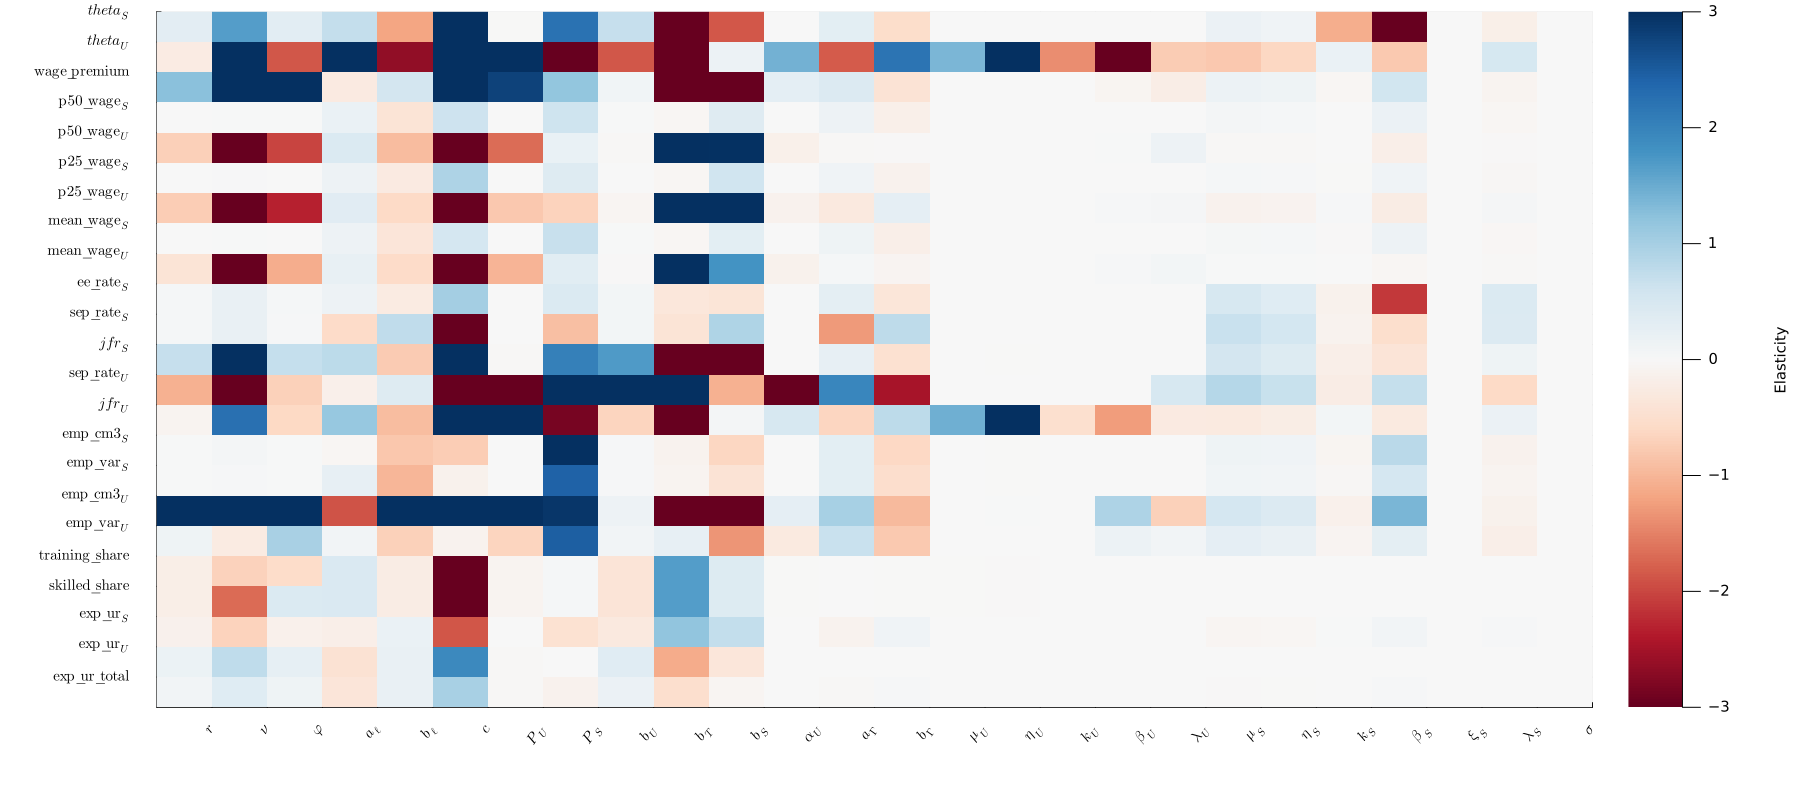

✓ Saved Jacobian heatmap to: /Users/ramzi.chariag/Documents/CEU/PhD/Research/Search and matching/code/notebooks/../../plots/one_run/moment_parameter_jacobian_base_fc_fullW.png


In [33]:
# ── Model-notation LaTeX labels for parameters ──────────────────────────────
const PARAM_LATEX = Dict{Symbol,LaTeXString}(
    :r        => L"r",
    :nu       => L"\nu",
    :phi      => L"\varphi",
    :a_l      => L"a_\ell",
    :b_l      => L"b_\ell",
    :c        => L"c",
    :PU       => L"P_U",
    :PS       => L"P_S",
    :bU       => L"b_U",
    :bT       => L"b_T",
    :bS       => L"b_S",
    :alpha_U  => L"\alpha_U",
    :a_Gam    => L"a_\Gamma",
    :b_Gam    => L"b_\Gamma",
    :unsk_mu  => L"\mu_U",
    :unsk_eta => L"\eta_U",
    :unsk_k   => L"k_U",
    :unsk_bet => L"\beta_U",
    :unsk_lam => L"\lambda_U",
    :skl_mu   => L"\mu_S",
    :skl_eta  => L"\eta_S",
    :skl_k    => L"k_S",
    :skl_bet  => L"\beta_S",
    :skl_xi   => L"\xi_S",
    :skl_lam  => L"\lambda_S",
    :skl_sig  => L"\sigma",
)

# ── Math-mode labels for moment names (e.g. :jfr_U → $jfr_U$) ────────────────
function moment_latex(m::Symbol)
    s    = String(m)
    toks = split(s, "_")
    if length(toks) >= 2 && length(toks[end]) == 1 && isuppercase(toks[end][1])
        sub = toks[end]
        if length(toks) == 2
            return latexstring(toks[1] * "_{" * sub * "}")
        else
            body = join(toks[1:end-1], "\\_")
            return latexstring("\\mathrm{" * body * "}_{" * sub * "}")
        end
    else
        return length(toks) == 1 ? latexstring(s) :
               latexstring("\\mathrm{" * replace(s, "_" => "\\_") * "}")
    end
end

p_labels_tex = [PARAM_LATEX[k] for k in PARAM_KEYS]
m_labels_tex = [moment_latex(m) for m in ACTIVE_MOMENTS]
E_clamp      = clamp.(E, -3.0, 3.0)

hm = heatmap(
    p_labels_tex, m_labels_tex, E_clamp;
    color           = :RdBu,
    clim            = (-3, 3),
    title           = "",
    xlabel          = "",
    ylabel          = "",
    xrotation       = 55,
    xticks          = (1:length(p_labels_tex), p_labels_tex),
    xtickfontsize   = 10,
    yticks          = (1:length(m_labels_tex), m_labels_tex),
    ytickfontsize   = 10,
    size            = (1800, max(400, 30*n_active + 120)),
    left_margin     = 8Plots.mm,
    bottom_margin   = 18Plots.mm,
    colorbar_title  = "Elasticity",
)
display(hm)

# ── Save to plots/one_run/moment_parameter_jacobian<scenario><weight>.png ────
plots_dir = joinpath(PROJECT_ROOT, "plots", "one_run")
isdir(plots_dir) || mkpath(plots_dir)
suffix    = "_" * SCENARIO_TAGS[ACTIVE_SCENARIO] * W_SUFFIX[ACTIVE_WEIGHTS]
save_path = joinpath(plots_dir, "moment_parameter_jacobian" * suffix * ".png")
savefig(hm, save_path)
println("✓ Saved Jacobian heatmap to: ", save_path)


## 15 · Σ̂ covariance structure (active moments)

Visualise the empirical covariance matrix from `data_pipeline_v6` to understand
which moments are statistically correlated.  The Σ̂ loaded here uses exactly the
same `SKIP_MOMENTS` filter as this notebook.

> **If the column count does not match `K_ACTIVE`**, the data pipeline needs to be
> re-run with the same `SKIP_MOMENTS` before proceeding.


In [34]:
if !isnothing(Sigma_emp) && size(Sigma_emp, 1) == n_active
    # Correlation matrix from Σ̂
    d_sig  = sqrt.(abs.(diag(Sigma_emp)))
    D_inv  = Diagonal(1.0 ./ max.(d_sig, 1e-14))
    Corr   = clamp.(D_inv * Sigma_emp * D_inv, -1.0, 1.0)

    p_corr = heatmap(
        m_short, m_short, Corr;
        aspect_ratio  = 1,
        color         = :RdBu,
        clims         = (-1, 1),
        colorbar      = true,
        title         = "Empirical correlation matrix Σ̂  ($(n_active) active moments, $ACTIVE_SCENARIO)",
        xrotation     = 45,
        xtickfontsize = 8,
        ytickfontsize = 8,
        size          = (900, 800),
        left_margin   = 6Plots.mm,
        bottom_margin = 12Plots.mm,
    )
    display(p_corr)

    # ── Top correlated pairs ──────────────────────────────────────────────────
    pairs_corr = [(abs(Corr[i,j]), m_short[i], m_short[j])
                  for i in 1:n_active for j in i+1:n_active]
    sort!(pairs_corr, rev=true)

    println("\nTop 15 correlated active-moment pairs (|r|):")
    println(rpad("Moment A", 24), rpad("Moment B", 24), "  |corr|")
    println("-" ^ 55)
    for (r, a, b) in pairs_corr[1:min(15, end)]
        @printf("  %-22s  %-22s  %.4f\n", a, b, r)
    end

    @printf("\nCondition number κ(Σ̂) for %s: %.2e\n", ACTIVE_SCENARIO, cond(Sigma_emp))
else
    if isnothing(Sigma_emp)
        println("Σ̂ not loaded — run data_pipeline_v6 Stage 8 first.")
    else
        @printf("Σ̂ size (%d×%d) does not match K_ACTIVE=%d.\n",
                size(Sigma_emp)..., n_active)
        println("Re-run Stage 8 of data_pipeline_v6 with the same SKIP_MOMENTS.")
    end
end


BoundsError: BoundsError: attempt to access 17-element Vector{String} at index [18]

## 16 · Joint identification: Jacobian + Σ̂

For each parameter, compute a **weighted** max-sensitivity score using the
diagonal of Σ̂ as precision weights: $\tilde{e}_i = \max_j |e_{j,i}| / \sqrt{\hat\sigma_{jj}}$.

High score = the parameter moves some moment that is also **precisely estimated**.
Low score  = either no moment responds, or only noisy moments respond.


In [35]:
if !isnothing(Sigma_emp) && size(Sigma_emp, 1) == n_active
    sigma_diag = diag(Sigma_emp)
    inv_sigma  = 1.0 ./ max.(sigma_diag, 1e-14)   # K_ACTIVE vector

    println()
    @printf("%-32s  %11s  %11s  %-20s\n",
            "Parameter", "Max|elas|", "Wtd score", "Best moment (raw elas)")
    println("-" ^ 80)

    for (i, pkey) in enumerate(PARAM_KEYS)
        col       = abs.(E[:, i])
        wtd       = col .* sqrt.(inv_sigma)         # precision-weighted
        max_raw   = maximum(col)
        max_wtd   = maximum(wtd)
        best_raw  = string(ACTIVE_MOMENTS[argmax(col)])
        flag      = max_raw < 0.1 ? "  ⚠ weak" : ""
        @printf("%-32s  %11.4f  %11.4f  %-20s%s\n",
                PARAM_LABELS[i], max_raw, max_wtd, best_raw, flag)
    end

    println()
    println("Wtd score = max_j |e_{j,i}| / sqrt(σ̂_{jj}):  higher → better identified.")
else
    println("Σ̂ not available — skipping weighted identification table.")
end



Parameter                           Max|elas|    Wtd score  Best moment (raw elas)
--------------------------------------------------------------------------------
discount rate r                        3.0992      92.0262  emp_cm3_U           
demographic exit ν                    18.9524     950.3306  emp_cm3_U           
training completion φ                 10.7647     257.7905  emp_cm3_U           
worker type shape a_ℓ                  3.2445      70.3897  theta_U             
worker type shape b_ℓ                  3.0675      50.1203  emp_cm3_U           
training cost c                      104.8046    1260.9471  theta_U             
unskilled productivity PU             22.9245     247.3330  theta_U             
skilled productivity PS                8.9678     141.4145  sep_rate_U          
unskilled UI flow bU                   5.2264      82.4167  sep_rate_U          
training flow bT                      36.9964    1174.9817  theta_U             
skilled UI flow bS       

## 17 · SMM-weighted Jacobian (W-norm)

Compute the squared norm of each parameter's Jacobian column under the SMM
weight matrix W:  $\|e_i\|_W^2 = e_i^\top W e_i$.

This directly measures how much the SMM objective $Q(\theta)$ responds to
parameter $i$, giving the most policy-relevant identification ranking.


In [36]:
if !isnothing(W_emp) && size(W_emp, 1) == n_active
    W_norms = [E[:, i]' * W_emp * E[:, i] for i in 1:n_params]

    println()
    @printf("%-32s  %12s  %-20s\n", "Parameter", "||e_i||²_W", "Best active moment")
    println("-" ^ 68)

    order_W = sortperm(W_norms; rev=true)
    for i in order_W
        col      = abs.(E[:, i])
        best_mom = string(ACTIVE_MOMENTS[argmax(col)])
        flag     = W_norms[i] < 1e-4 ? "  ⚠ weak" : ""
        @printf("%-32s  %12.4e  %-20s%s\n",
                PARAM_LABELS[i], W_norms[i], best_mom, flag)
    end

    println()
    println("||e_i||²_W = eᵢᵀ W eᵢ: how much the SMM loss Q(θ) responds to parameter i.")
    println("Low W-norm → parameter barely affects Q → consider fixing or re-targeting.")

    # Heatmap of Jacobian under W-weighting
    WE        = W_emp * E          # (K_active × n_params) — W-rotated Jacobian
    WE_clamp  = clamp.(WE, -3.0, 3.0)

    hm_W = heatmap(
        p_abbr, m_short, WE_clamp;
        color           = :RdBu,
        clim            = (-3, 3),
        title           = "W-weighted Jacobian  W·E  (clamped [-3,3], $ACTIVE_SCENARIO)",
        xlabel          = "Parameter",
        ylabel          = "Active moment",
        xrotation       = 55,
        xticks          = (1:length(p_abbr), p_abbr),
        xtickfontsize   = 8,
        yticks          = (1:length(m_short), m_short),
        ytickfontsize   = 9,
        size            = (1800, max(400, 30*n_active + 120)),
        left_margin     = 8Plots.mm,
        bottom_margin   = 22Plots.mm,
        colorbar_title  = "W·Elasticity",
    )
    display(hm_W)
else
    println("W matrix not available or size mismatch — skipping W-norm ranking.")
    println("Run data_pipeline_v6 Stage 8 with the same SKIP_MOMENTS.")
end


W matrix not available or size mismatch — skipping W-norm ranking.
Run data_pipeline_v6 Stage 8 with the same SKIP_MOMENTS.


## 18 · Model vs data moment comparison

Side-by-side table of baseline model moments against empirical targets
for the active scenario window (restricted to active moments).


In [37]:
if !isempty(data_moments)
    sep = "=" ^ 72
    println("\n", sep)
    println("  MODEL vs DATA — active moments")
    println("  scenario : $ACTIVE_SCENARIO")
    println(sep)
    @printf("  %-22s  %12s  %12s  %10s\n",
            "Moment", "Model", "Data target", "Δ (m−d)")
    println("-" ^ 62)

    for mname in ACTIVE_MOMENTS
        mv   = getfield(m_base, mname)
        dv   = get(data_moments, mname, NaN)
        flag = (isfinite(dv) && isfinite(mv) &&
                abs(mv - dv) > 0.5 * abs(dv) + 1e-8) ? "  ◄" : ""
        @printf("  %-22s  %12.6f  %12s  %s%s\n",
                string(mname), mv,
                isfinite(dv) ? @sprintf("%12.6f", dv) : "    —",
                isfinite(dv) ? @sprintf("%+10.4f", mv - dv) : "    —",
                flag)
    end
    println(sep)
    println("◄ = |model − data| > 50 % of data target")
else
    println("Empirical moments not loaded — run data_pipeline_v6 Stage 7 first.")
end



  MODEL vs DATA — active moments
  scenario : base_fc
  Moment                         Model   Data target     Δ (m−d)
--------------------------------------------------------------
  exp_ur_total                1.371003      1.054339     +0.3167
  exp_ur_U                    1.381825      1.066056     +0.3158
  exp_ur_S                    1.343512      1.026366     +0.3171
  skilled_share               0.279618      0.291534     -0.0119
  training_share              0.483355      0.033441     +0.4499  ◄
  emp_var_U                   0.149013      0.254256     -0.1052
  emp_cm3_U                   0.017679      0.170862     -0.1532  ◄
  emp_var_S                   0.263792      0.393375     -0.1296
  emp_cm3_S                   0.123669      0.233732     -0.1101
  jfr_U                       0.013203      0.261049     -0.2478  ◄
  sep_rate_U                  0.053577      0.015135     +0.0384  ◄
  jfr_S                       0.178962      0.274119     -0.0952
  sep_rate_S             

## 19 · Summary diagnostics

Print convergence warnings, weakly-identified parameters, and SKIP_MOMENTS sync check.


In [38]:
println("=" ^ 70)
println("  SENSITIVITY ANALYSIS SUMMARY")
println("  scenario : $ACTIVE_SCENARIO   weights : $ACTIVE_WEIGHTS")
println("  active moments : $n_active / $(length(MOMENT_NAMES))")
println("=" ^ 70)

# Convergence warnings
bad_plus  = findall(.!conv_plus)
bad_minus = findall(.!conv_minus)
if !isempty(bad_plus) || !isempty(bad_minus)
    println("\n⚠ Convergence warnings:")
    for i in union(bad_plus, bad_minus)
        println("   $(PARAM_LABELS[i])  (plus=$(conv_plus[i]), minus=$(conv_minus[i]))")
    end
end

# Weakly-identified parameters
weak = [PARAM_LABELS[i] for i in 1:n_params if maximum(abs.(E[:, i])) < 0.1]
if !isempty(weak)
    println("\n⚠ Weakly identified parameters (max |elas| < 0.1 over active moments):")
    for w in weak; println("   • ", w); end
else
    println("\n✓ All parameters have at least one active moment with |elas| ≥ 0.1.")
end

# SKIP_MOMENTS sync check
if !isnothing(Sigma_emp)
    if size(Sigma_emp, 1) == n_active
        println("\n✓ Σ̂ dimension ($(size(Sigma_emp,1))) matches K_ACTIVE ($n_active).")
    else
        println("\n⚠ Σ̂ dimension ($(size(Sigma_emp,1))) ≠ K_ACTIVE ($n_active).")
        println("  → Re-run Stage 8 of data_pipeline_v6 with the same SKIP_MOMENTS.")
    end
end

println()
println("Skipped moments : ",
        isempty(SKIP_MOMENTS) ? "none" : join(string.(SKIP_MOMENTS), ", "))
println("=" ^ 70)


  SENSITIVITY ANALYSIS SUMMARY
  scenario : base_fc   weights : full
  active moments : 23 / 26

⚠ Weakly identified parameters (max |elas| < 0.1 over active moments):
   • skilled exog sep rate ξ_S
   • OJS flow cost σ

✓ Σ̂ dimension (23) matches K_ACTIVE (23).

Skipped moments : ur_total, ur_U, ur_S
